In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Tabela4.csv', sep=';', decimal=',', encoding='latin-1', skiprows=1)

In [4]:
df

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759
5,CE,23,Ceará,0.405,0.541,0.682,0.709,0.712,0.717,0.723,0.727,0.737,0.746,0.754,0.753,0.740,0.759,0.773,0.773
6,DF,53,Distrito Federal,0.616,0.725,0.824,0.824,0.834,0.834,0.833,0.842,0.842,0.845,0.860,0.837,0.823,0.867,0.870,0.866
7,ES,32,Espírito Santo,0.505,0.640,0.740,0.747,0.755,0.763,0.766,0.766,0.769,0.776,0.780,0.773,0.754,0.782,0.803,0.804
8,GO,52,Goiás,0.487,0.615,0.735,0.744,0.753,0.759,0.758,0.765,0.770,0.776,0.780,0.777,0.755,0.797,0.809,0.815
9,MA,21,Maranhão,0.357,0.476,0.639,0.669,0.682,0.683,0.690,0.698,0.704,0.706,0.715,0.715,0.701,0.730,0.740,0.745


In [5]:
anos = [c for c in df.columns if str(c).isdigit()]
print(anos)

['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [6]:
id_vars = [c for c in df.columns if c not in anos]
df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")
df_longo.head()


,Sigla,Código,Estado,Ano,IDH
0,AC,12,Acre,1991,0.402
1,AL,27,Alagoas,1991,0.370
2,AM,13,Amazonas,1991,0.430
3,AP,16,Amapá,1991,0.472
4,BA,29,Bahia,1991,0.386


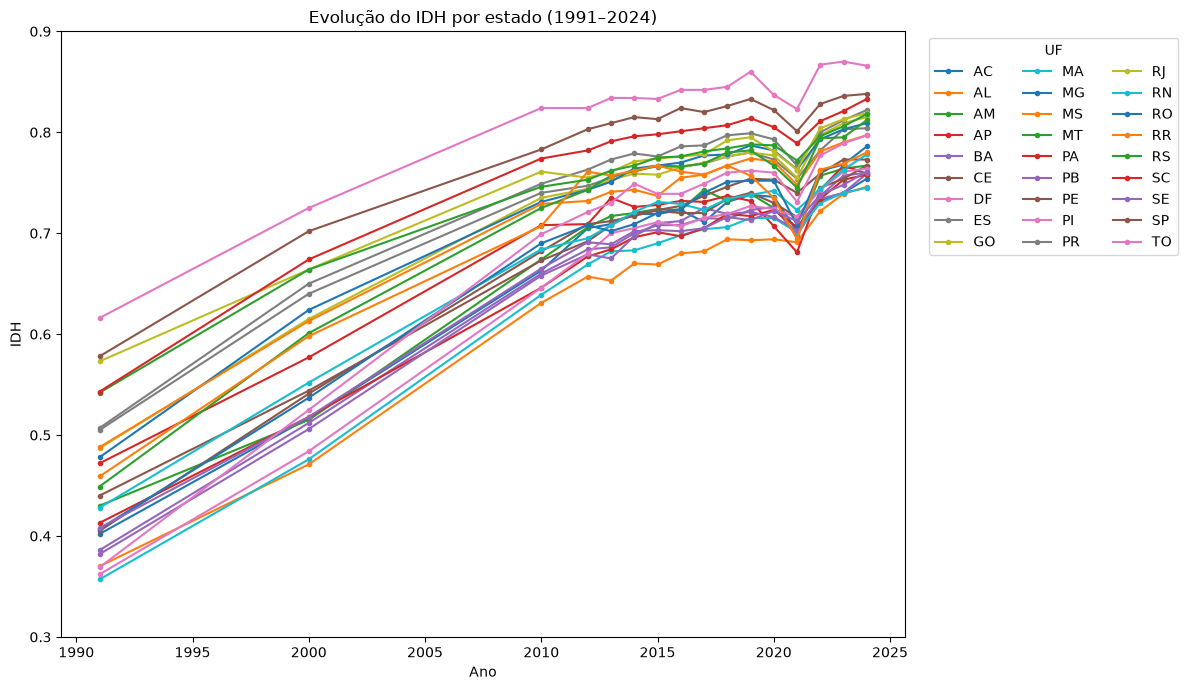

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()

In [8]:
df_2024 = df.sort_values('2024', ascending=False).reset_index(drop=True)
print(df_2024[['Sigla', '2024']])

   Sigla   2024
0     DF  0.866
1     SP  0.838
2     SC  0.833
3     PR  0.822
4     RJ  0.819
5     RS  0.818
6     GO  0.815
7     MT  0.812
8     MG  0.809
9     ES  0.804
10    TO  0.797
11    MS  0.797
12    RO  0.786
13    RR  0.780
14    RN  0.778
15    CE  0.773
16    AM  0.767
17    PE  0.767
18    PI  0.764
19    SE  0.761
20    PB  0.760
21    BA  0.759
22    AP  0.759
23    PA  0.758
24    AC  0.754
25    AL  0.746
26    MA  0.745


In [19]:
df['diferenca'] = df['2024'] - df['1991']
melhor = df.loc[df['diferenca'].idxmax()]
print(f"\n{melhor['Estado']} "
      f"{melhor['1991']:.3f}  {melhor['2024']:.3f}")


Tocantins 0.369  0.797


In [21]:
piores = df[df['diferenca'] < 0]
if piores.empty:
    print("\nNenhum")
else:
    print("\nEstados com IDH piorado:")
    print(piores[['Estado', 1991, 2024, 'diferenca']].to_string(index=False))


Nenhum


In [32]:
anos = [c for c in df.columns if c.isdigit()]

longo = df.melt(
    id_vars='Estado',
    value_vars=anos,
    var_name='Ano',
    value_name='IDH'
)

# Converte Ano para int para ordenar corretamente
longo['Ano'] = longo['Ano'].astype(int)
longo = longo.sort_values(['Estado', 'Ano']).reset_index(drop=True)   
longo

,Estado,Ano,IDH
0,Acre,1991,0.402
1,Acre,2000,0.517
2,Acre,2010,0.663
3,Acre,2012,0.705
4,Acre,2013,0.709
...,...,...,...
427,Tocantins,2020,0.760
428,Tocantins,2021,0.731
429,Tocantins,2022,0.777
430,Tocantins,2023,0.789


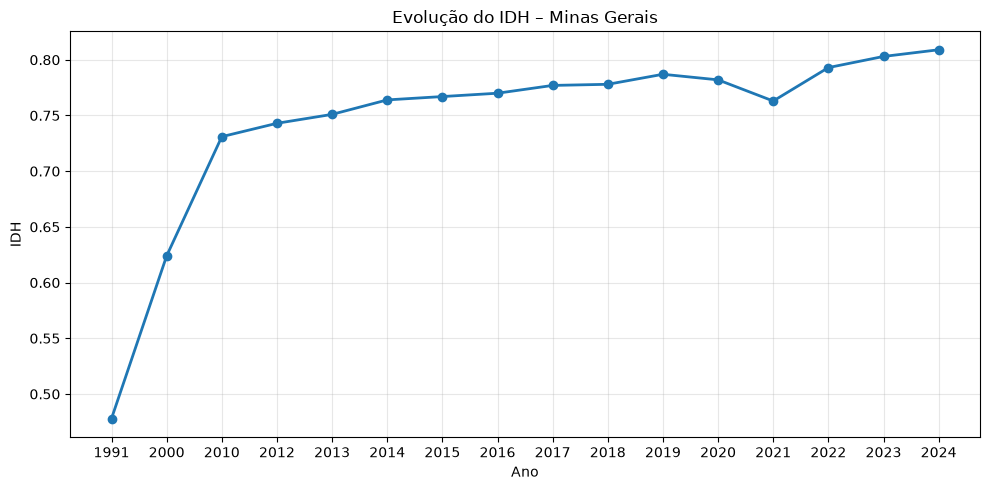

In [25]:
mg = df_long[df_long['Estado'] == 'Minas Gerais']

plt.figure(figsize=(10, 5))
plt.plot(mg['Ano'], mg['IDH'], marker='o', linewidth=2)
plt.title('Evolução do IDH – Minas Gerais')
plt.xlabel('Ano')
plt.ylabel('IDH')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

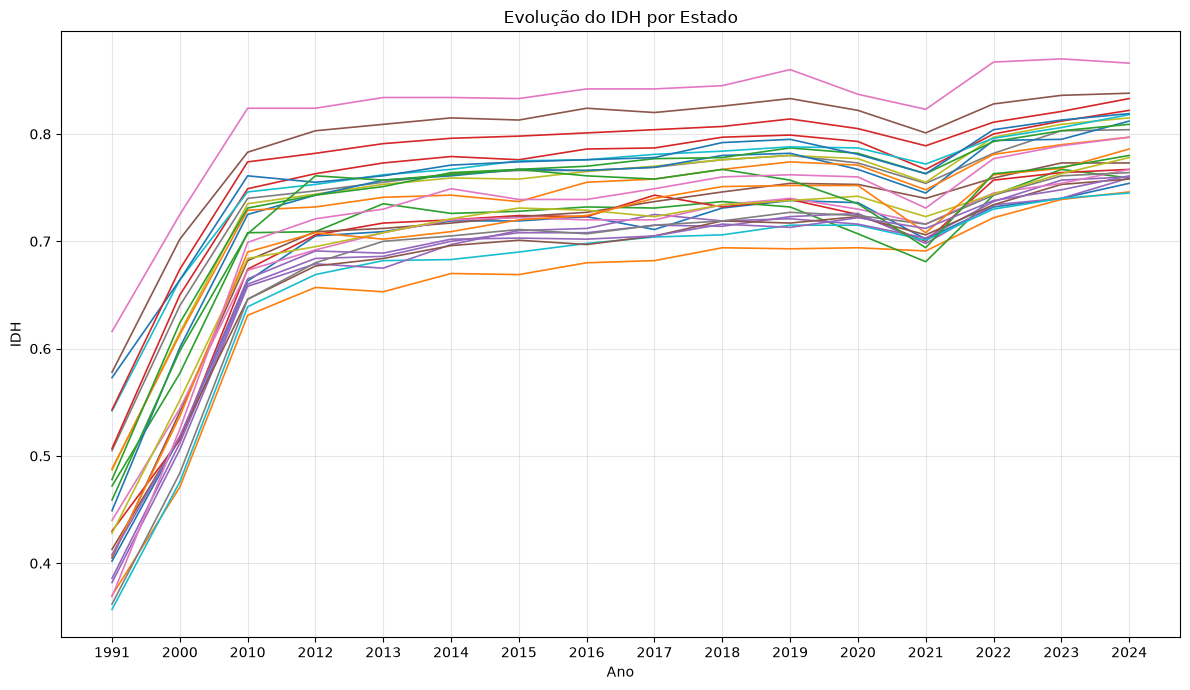

In [27]:
plt.figure(figsize=(12, 7))
for estado, grupo in df_long.groupby('Estado'):
    plt.plot(grupo['Ano'], grupo['IDH'], label=estado, linewidth=1.2)

plt.title('Evolução do IDH por Estado')
plt.xlabel('Ano')
plt.ylabel('IDH')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()